# Додаткове завдання: колаборативна фільтрація з нуля

У цьому ноутбуці реалізовано алгоритм матричної факторизації без використання `Surprise`.

Ми реалізуємо:

- завантаження датасету `movies.mat`;
- завантаження назв фільмів `movie_ids.txt`;
- функцію втрат `cofiCostFunc`;
- градієнти для `X` та `W`;
- регуляризацію;
- gradient checking;
- навчання через `scipy.optimize.minimize`;
- рекомендації фільмів для користувача.


## 1. Встановлення та імпорт бібліотек

In [1]:
!pip install gdown scipy matplotlib pandas numpy


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat
from scipy.optimize import minimize

np.random.seed(42)


## 2. Завантаження файлів з Google Drive

Файли із завдання:

- `movie_ids.txt` — назви фільмів;
- `movies.mat` — матриці рейтингів `Y` та `R`.


In [3]:
# ID файлів з Google Drive
movie_ids_file_id = '12XeO4KXQfbvvTdLFbkYA-BeXzhlNnnuo'
movies_mat_file_id = '17V9OhXeZH9Wv17Nkh-Tqxa8svEmRZcIp'

if not os.path.exists('movie_ids.txt'):
    !gdown --id 12XeO4KXQfbvvTdLFbkYA-BeXzhlNnnuo -O movie_ids.txt

if not os.path.exists('movies.mat'):
    !gdown --id 17V9OhXeZH9Wv17Nkh-Tqxa8svEmRZcIp -O movies.mat

print('Файли завантажено')


/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=12XeO4KXQfbvvTdLFbkYA-BeXzhlNnnuo
To: /content/movie_ids.txt
100% 48.4k/48.4k [00:00<00:00, 16.4MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=17V9OhXeZH9Wv17Nkh-Tqxa8svEmRZcIp
From (redirected): https://drive.google.com/uc?id=17V9OhXeZH9Wv17Nkh-Tqxa8svEmRZcIp&confirm=t&uuid=84bbc860-6bc1-4769-85cd-47efbedc6f1d
To: /content/movies.mat
100% 223k/223k [00:00<00:00, 92.8MB/s]
Файли завантажено


## 3. Функція для читання назв фільмів

У вихідному коді із завдання була синтаксична помилка:

```python
with open('movie_ids.txt'),  encoding='ISO-8859-1') as fid:
```

Правильний варіант:

In [4]:
def loadMovieList(filename='movie_ids.txt'):
    """
    Reads movie_ids.txt and returns a list of movie names.
    """
    with open(filename, encoding='ISO-8859-1') as fid:
        movies = fid.readlines()

    movieNames = []
    for movie in movies:
        parts = movie.split()
        movieNames.append(' '.join(parts[1:]).strip())

    return movieNames

movieList = loadMovieList()
print('Кількість фільмів:', len(movieList))
print(movieList[:10])


Кількість фільмів: 1682
['Toy Story (1995)', 'GoldenEye (1995)', 'Four Rooms (1995)', 'Get Shorty (1995)', 'Copycat (1995)', 'Shanghai Triad (Yao a yao yao dao waipo qiao) (1995)', 'Twelve Monkeys (1995)', 'Babe (1995)', 'Dead Man Walking (1995)', 'Richard III (1995)']


## 4. Завантаження матриць `Y` та `R`

- `Y` — матриця рейтингів розміру `num_movies × num_users`;
- `R` — бінарна матриця, де `R[i, j] = 1`, якщо користувач `j` оцінив фільм `i`.

In [5]:
data = loadmat('movies.mat')
Y = data['Y']
R = data['R']

print('Y shape:', Y.shape)
print('R shape:', R.shape)

# Приклад: середній рейтинг фільму з індексом 1600
movie_idx = 1600
avg_rating = np.mean(Y[movie_idx, R[movie_idx, :] == 1])
print(f'Average rating for movie {movie_idx + 1} ({movieList[movie_idx]}): {avg_rating:.2f} / 5')


Y shape: (1682, 943)
R shape: (1682, 943)
Average rating for movie 1601 (Office Killer (1997)): 1.00 / 5


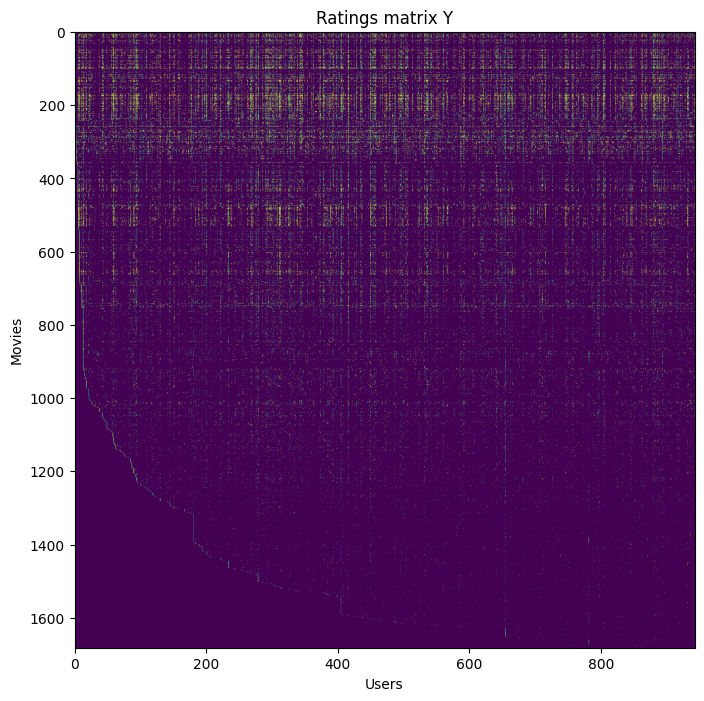

In [6]:
plt.figure(figsize=(8, 8))
plt.imshow(Y, aspect='auto')
plt.ylabel('Movies')
plt.xlabel('Users')
plt.title('Ratings matrix Y')
plt.grid(False)
plt.show()


## 5. Функція втрат та градієнт

Прогноз рейтингу:

$$\hat{Y} = XW^T$$

Функція втрат з регуляризацією:

$$J = \frac{1}{2}\sum_{(i,j):R_{ij}=1}(X_i W_j^T - Y_{ij})^2 + \frac{\lambda}{2}\sum_i \sum_k X_{ik}^2 + \frac{\lambda}{2}\sum_j \sum_k W_{jk}^2$$

In [7]:
def cofiCostFunc(params, Y, R, num_users, num_movies, num_features, lambda_=0.0):
    """
    Collaborative filtering cost function and gradient.

    Parameters
    ----------
    params : ndarray
        Unrolled parameters X and W.
    Y : ndarray
        Ratings matrix, shape = (num_movies, num_users).
    R : ndarray
        Indicator matrix, shape = (num_movies, num_users).
    num_users : int
    num_movies : int
    num_features : int
    lambda_ : float
        Regularization parameter.

    Returns
    -------
    J : float
        Cost value.
    grad : ndarray
        Unrolled gradient vector.
    """
    # Відновлюємо X та W з одного вектора params
    X = params[:num_movies * num_features].reshape(num_movies, num_features)
    W = params[num_movies * num_features:].reshape(num_users, num_features)

    # Помилка тільки для тих рейтингів, які існують: R == 1
    error = (X @ W.T - Y) * R

    # Cost function
    J = 0.5 * np.sum(error ** 2)

    # Regularization
    J += (lambda_ / 2) * np.sum(W ** 2)
    J += (lambda_ / 2) * np.sum(X ** 2)

    # Gradients
    X_grad = error @ W + lambda_ * X
    W_grad = error.T @ X + lambda_ * W

    grad = np.concatenate([X_grad.ravel(), W_grad.ravel()])

    return J, grad


## 6. Перевірка функції втрат на маленькому прикладі

In [8]:
# Маленький піднабір даних для швидкої перевірки
num_users_small = 4
num_movies_small = 5
num_features_small = 3

X_small = np.random.randn(num_movies_small, num_features_small)
W_small = np.random.randn(num_users_small, num_features_small)

Y_small = Y[:num_movies_small, :num_users_small]
R_small = R[:num_movies_small, :num_users_small]

params_small = np.concatenate([X_small.ravel(), W_small.ravel()])

J, grad = cofiCostFunc(
    params_small,
    Y_small,
    R_small,
    num_users_small,
    num_movies_small,
    num_features_small,
    lambda_=1.5
)

print('Cost on small example:', J)
print('Gradient shape:', grad.shape)


Cost on small example: 65.29429899106691
Gradient shape: (27,)


## 7. Gradient checking

Чисельно перевіримо, чи правильно пораховано градієнти.

In [9]:
def computeNumericalGradient(cost_func, params, epsilon=1e-4):
    numgrad = np.zeros_like(params)
    perturb = np.zeros_like(params)

    for p in range(len(params)):
        perturb[p] = epsilon
        loss1, _ = cost_func(params - perturb)
        loss2, _ = cost_func(params + perturb)
        numgrad[p] = (loss2 - loss1) / (2 * epsilon)
        perturb[p] = 0

    return numgrad


def checkCostFunction(lambda_=0.0):
    num_users = 4
    num_movies = 5
    num_features = 3

    X_t = np.random.randn(num_movies, num_features)
    W_t = np.random.randn(num_users, num_features)
    Y_t = X_t @ W_t.T

    # Випадково прибираємо частину рейтингів
    R_t = (np.random.rand(num_movies, num_users) > 0.5).astype(int)
    Y_t = Y_t * R_t

    X = np.random.randn(num_movies, num_features)
    W = np.random.randn(num_users, num_features)
    params = np.concatenate([X.ravel(), W.ravel()])

    def cost_func(p):
        return cofiCostFunc(p, Y_t, R_t, num_users, num_movies, num_features, lambda_)

    cost, grad = cost_func(params)
    numgrad = computeNumericalGradient(cost_func, params)

    diff = np.linalg.norm(numgrad - grad) / np.linalg.norm(numgrad + grad)

    print('Relative Difference:', diff)
    print('Якщо все правильно, різниця має бути меншою за 1e-9 або дуже близькою до цього.')

checkCostFunction(lambda_=0.0)
checkCostFunction(lambda_=1.5)


Relative Difference: 1.7744110546287164e-12
Якщо все правильно, різниця має бути меншою за 1e-9 або дуже близькою до цього.
Relative Difference: 3.198341798958063e-12
Якщо все правильно, різниця має бути меншою за 1e-9 або дуже близькою до цього.


## 8. Додавання власних рейтингів

Тут можна задати власні оцінки для кількох фільмів. Індекси в Python починаються з `0`, тому `my_ratings[0]` відповідає першому фільму в списку.

In [10]:
my_ratings = np.zeros(len(movieList))

# Приклади оцінок від 1 до 5
my_ratings[0] = 4      # Toy Story
my_ratings[97] = 2
my_ratings[6] = 3
my_ratings[11] = 5
my_ratings[53] = 4
my_ratings[63] = 5
my_ratings[65] = 3
my_ratings[68] = 5
my_ratings[182] = 4
my_ratings[225] = 5
my_ratings[354] = 5

print('Власні рейтинги:')
for i, rating in enumerate(my_ratings):
    if rating > 0:
        print(f'Rated {int(rating)} for {movieList[i]}')


Власні рейтинги:
Rated 4 for Toy Story (1995)
Rated 3 for Twelve Monkeys (1995)
Rated 5 for Usual Suspects, The (1995)
Rated 4 for Outbreak (1995)
Rated 5 for Shawshank Redemption, The (1994)
Rated 3 for While You Were Sleeping (1995)
Rated 5 for Forrest Gump (1994)
Rated 2 for Silence of the Lambs, The (1991)
Rated 4 for Alien (1979)
Rated 5 for Die Hard 2 (1990)
Rated 5 for Sphere (1998)


## 9. Нормалізація рейтингів

Для матричної факторизації корисно нормалізувати рейтинги, віднявши середній рейтинг кожного фільму.

In [11]:
def normalizeRatings(Y, R):
    m, n = Y.shape
    Ymean = np.zeros(m)
    Ynorm = np.zeros(Y.shape)

    for i in range(m):
        idx = R[i, :] == 1
        if np.sum(idx) > 0:
            Ymean[i] = np.mean(Y[i, idx])
            Ynorm[i, idx] = Y[i, idx] - Ymean[i]

    return Ynorm, Ymean

# Додаємо власні рейтинги як нового користувача
Y_with_my = np.column_stack([my_ratings, Y])
R_with_my = np.column_stack([(my_ratings != 0).astype(int), R])

Ynorm, Ymean = normalizeRatings(Y_with_my, R_with_my)

print('Ynorm shape:', Ynorm.shape)
print('Ymean shape:', Ymean.shape)


Ynorm shape: (1682, 944)
Ymean shape: (1682,)


## 10. Навчання моделі

Для швидшого виконання використаємо `num_features = 10`. У завданні можна використовувати `100`, але це буде значно довше.

In [12]:
num_movies, num_users = Ynorm.shape
num_features = 10
lambda_ = 10

# Випадкова ініціалізація параметрів
X = np.random.randn(num_movies, num_features)
W = np.random.randn(num_users, num_features)
initial_params = np.concatenate([X.ravel(), W.ravel()])

print('num_movies:', num_movies)
print('num_users:', num_users)
print('num_features:', num_features)
print('initial_params shape:', initial_params.shape)


num_movies: 1682
num_users: 944
num_features: 10
initial_params shape: (26260,)


In [15]:
def cost_for_minimize(params):
    J, grad = cofiCostFunc(
        params,
        Ynorm,
        R_with_my,
        num_users,
        num_movies,
        num_features,
        lambda_
    )
    return J, grad

result = minimize(
    fun=cost_for_minimize,
    x0=initial_params,
    method='TNC',
    jac=True,
    options={'maxfun': 300}
)

print('Optimization success:', result.success)
print('Final cost:', result.fun)


Optimization success: False
Final cost: 38951.85278402183


## 11. Рекомендації фільмів

Після навчання моделі отримаємо прогнозовані рейтинги для нового користувача.

In [16]:
learned_params = result.x

X_learned = learned_params[:num_movies * num_features].reshape(num_movies, num_features)
W_learned = learned_params[num_movies * num_features:].reshape(num_users, num_features)

# Прогнозовані рейтинги
predictions = X_learned @ W_learned.T

# Для нового користувача беремо першу колонку + додаємо назад середнє значення
my_predictions = predictions[:, 0] + Ymean

recommended_movie_indices = np.argsort(my_predictions)[::-1]

print('Top recommendations for you:')
print()

count = 0
for i in recommended_movie_indices:
    if my_ratings[i] == 0:
        print(f'Predicting rating {my_predictions[i]:.2f} for movie {movieList[i]}')
        count += 1
    if count == 10:
        break


Top recommendations for you:

Predicting rating 5.00 for movie Entertaining Angels: The Dorothy Day Story (1996)
Predicting rating 5.00 for movie Santa with Muscles (1996)
Predicting rating 5.00 for movie Aiqing wansui (1994)
Predicting rating 5.00 for movie Star Kid (1997)
Predicting rating 5.00 for movie Marlene Dietrich: Shadow and Light (1996)
Predicting rating 5.00 for movie They Made Me a Criminal (1939)
Predicting rating 5.00 for movie Saint of Fort Washington, The (1993)
Predicting rating 5.00 for movie Great Day in Harlem, A (1994)
Predicting rating 5.00 for movie Someone Else's America (1995)
Predicting rating 5.00 for movie Prefontaine (1997)


## 12. Висновок

У цьому додатковому завданні було реалізовано алгоритм колаборативної фільтрації з нуля.

Основна ідея полягає в тому, що матриця рейтингів розкладається на дві матриці:

- `X` — латентні ознаки фільмів;
- `W` — латентні ознаки користувачів.

Прогноз рейтингу обчислюється як добуток:

$$\hat{Y} = XW^T$$

Модель навчається шляхом мінімізації квадратичної помилки тільки для тих рейтингів, які реально існують, тобто для елементів, де `R = 1`. Для уникнення перенавчання використано регуляризацію.